<a href="https://colab.research.google.com/github/mp-codez/probability-statistics-experiments/blob/solution/kde_problems_and_solutions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##### What is the probability distribution of age in the insurance dataset?

In [ ]:
import pandas as pd

In [20]:
# Example: Titanic CSV from GitHub
url = "https://github.com/mp-codez/dataset/blob/main/insurance.csv?raw=true"

In [22]:
insurance = pd.read_csv(url)
insurance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


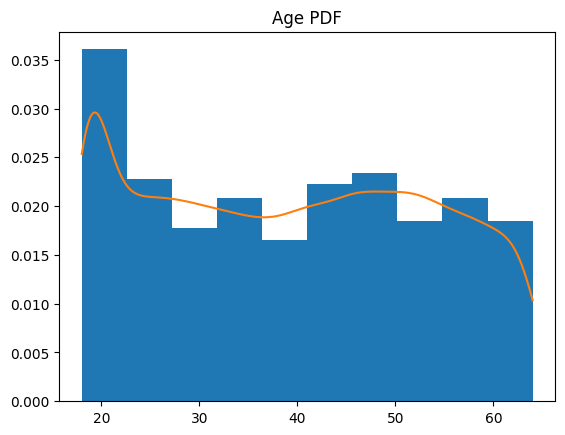

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sea
from sklearn.neighbors import KernelDensity

#Load the data
df = insurance

#Plot histogram
plt.hist(df['age'], density=True)

#create sample age 2D data
sample_age_data = df['age'].to_numpy().reshape(-1, 1)

#Create KernelDensity Object
model = KernelDensity(bandwidth=1.8, kernel="gaussian")
kde = model.fit(sample_age_data)

# Evaluate PDF over age range
age_range = np.linspace(df['age'].to_numpy().min(), df['age'].to_numpy().max(), 1000)
probability_distribution  = kde.score_samples(age_range.reshape(-1, 1))
probability_distribution = np.exp(probability_distribution)


#Plot PDF
plt.plot(age_range, probability_distribution)
plt.title('Age PDF')
plt.show()